In [ ]:
import netket as nk
import jax
from netket.operator.spin import sigmax,sigmaz
from jax import numpy as jnp
import matplotlib.pyplot as plt
import pickle
import optax
from flax import linen as nn
from functools import partial
from netket import jax as nkjax

∣NK⟩ Tip: Use driver.run(..., timeit=True) to know where your dominant cost is.

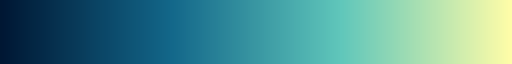

In [ ]:
from matplotlib.colors import ListedColormap
from matplotlib.colors import LinearSegmentedColormap
import matplotlib.patches as patches

custom_palette = ['#001733', '#13678A', '#60C7BB', '#FFFDA8']
cmap_blue = LinearSegmentedColormap.from_list("custom_cmap", ['#001733', '#13678A', '#60C7BB', '#FFFDA8'])
cmap_blue

# Tutorial — J₁–J₂ model (toy example)

In this tutorial we use the **J₁–J₂ model** as a compact toy example to demonstrate the main qdisc tools.
We work on a $3\times 3$ square lattice with **open boundary conditions** and fix $J_1 = 1$. 
The Hamiltonian is

$$
H_{J_1J_2}
=
\sum_{\langle i,j\rangle} \sigma_i^z \sigma_j^z
+ J_2 \sum_{\langle\langle i,j \rangle\rangle} \sigma_i^z \sigma_j^z
+ h\sum_i \sigma_i^x,
$$

where $\langle
\cdot\rangle$ and $\langle\langle \cdot\rangle\rangle$ denote nearest-neighbour (NN) and next-nearest-neighbour (NNN) pairs, respectively.

We treat the experimental tuning parameters as
- $\theta_1 = J_2 \in [0,\,1.5]$, and
- $\theta_2 = h \in [0.1,\,2]$.

In the following cells we will:
1. generate raw quantum data
2. train a VAE to learn a latent representation of the phase space,
3. inspect active latent variables and visualize the learned structure across $(\theta_1,\theta_2)$,
4. apply symbolic regression (SR) methods to extract compact analytic descriptors for the latent clusters.

## Generating quantum data

We begin by generating raw quantum data for the system. In this tutorial, the data consist of **measurement snapshots in the $\sigma^z$ basis**.

To obtain these snapshots, we proceed as follows:
1. Perform an **exact diagonalization** of the Hamiltonian for a range of tuning parameter values $(\theta_1,\theta_2)$.
2. Use the resulting ground-state wavefunction to compute measurement probabilities.
3. Sample snapshots from these probabilities in the $\sigma^z$ measurement basis.

The construction of the Hamiltonian and the exact diagonalization are carried out using **NetKet**, a powerful library for computational quantum physics.

For more details on NetKet and its capabilities, we refer the reader to the official documentation:
$$
\texttt{https://www.netket.org/}
$$


In [ ]:
nk.config.netket_spin_ordering_warning = False

In [ ]:
## We define the Hamitonian using the NetKet Paulis operators ##

N = 9
hi = nk.hilbert.Spin(s=1/2, N=N)


def get_H(J1,J2,h,N=N):
    '''J1J2 Hamiltonian'''

    #NN interactions
    NN = [(0,1),(0,5),(1,4),(1,2),(2,3),(5,6),(5,4),(4,7),(4,3),(3,8),(6,7),(7,8)]
    H = sum([J1*sigmaz(hi,i)@sigmaz(hi,j) for i,j in NN])
    #NNN interactions
    NNN = [(0,4),(5,1),(1,3),(4,2),(5,7),(6,4),(4,8),(7,3)]
    H += sum([J2*sigmaz(hi,i)@sigmaz(hi,j) for i,j in NNN])
    #External field
    H += sum([h*sigmax(hi,i) for i in range(N)])

    return H

In [ ]:
## we perform an exact diagonalization using the lanczos algorithm implemented in NetKet ##

#size of the system
N = 9

#define the various observables we want to compute
NN = [(0,1),(0,5),(1,4),(1,2),(2,3),(5,6),(5,4),(4,7),(4,3),(3,8),(6,7),(7,8)]
NNN = [(0,4),(5,1),(1,3),(4,2),(5,7),(6,4),(4,8),(7,3)]
corr_op = sum([sigmaz(hi,i)@sigmaz(hi,j) for i,j in NN])
corr2_op = sum([sigmaz(hi,i)@sigmaz(hi,j) for i,j in NNN])

#H parameters
J1 = 1.
all_J2 = jnp.linspace(0, 1.5, 21)
all_h = jnp.linspace(0, 2., 21)[1:]

#containers for the observables
energies = jnp.zeros((len(all_J2),len(all_h)))
wave_fcts = jnp.zeros((len(all_J2), len(all_h), 2**N, 1))
corr_gs = jnp.zeros((len(all_J2),len(all_h)))
corr2_gs = jnp.zeros((len(all_J2),len(all_h)))

#exact diagonalization for every set of parameter of H
for i, J2 in enumerate(all_J2):
  for j, h in enumerate(all_h):

        #print('J2: {}, h: {}'.format(J2,h))

        H = get_H(J1,J2,h,N=N)
        E_gs, ket_gs = nk.exact.lanczos_ed(H, compute_eigenvectors=True)


        corr = (ket_gs.T.conj()@corr_op.to_linear_operator()@ket_gs).real[0,0]
        corr2 = (ket_gs.T.conj()@corr2_op.to_linear_operator()@ket_gs).real[0,0]


        energies = energies.at[i,j].set(E_gs[0])
        wave_fcts = wave_fcts.at[i,j].set(ket_gs)
        corr_gs = corr_gs.at[i,j].set(corr)
        corr2_gs = corr2_gs.at[i,j].set(corr2)


data_exact = {'energies': energies, 'wave_fcts': wave_fcts, 'corr_gs': corr_gs, 'corr2_gs': corr2_gs}

Across the explored parameter space, the system exhibits **three distinct phases**.

For small $J_2$ and weak transverse field $h$, the nearest-neighbour interactions dominate. This regime shows a **Néel-ordered phase**, characterized by antialigned nearest-neighbour spins.

For large $J_2$ and small $h$, the next-nearest-neighbour couplings become dominant. The system then enters a **striped phase**, in which nearest-neighbour spins align while next-nearest-neighbour spins are antialigned.

Finally, for sufficiently large transverse field $h$, the spins polarize along the $x$ direction, forming a **polarized phase**.


We can visualize the phase space by looking at the next-nearest-neighbor correlator:

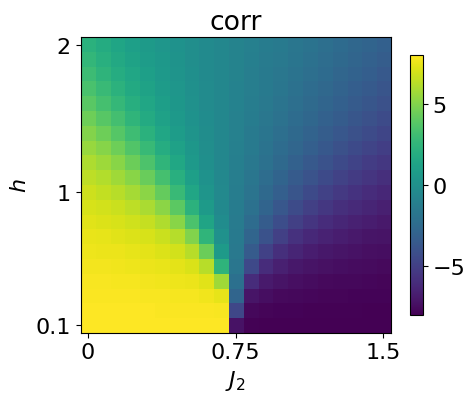

In [ ]:
plt.rcParams['font.size'] = 16
plt.figure(figsize=(5,5),dpi=100)

plt.imshow(jnp.rot90(data_exact['corr2_gs']))
plt.ylabel(r'$h$')
plt.xlabel(r'$J_2$')
plt.colorbar(shrink=0.675)
plt.title(r'corr')


y_tick_positions = [0,10,19]
y_tick_labels = ['2', '1', '0.1']
plt.yticks(y_tick_positions, y_tick_labels)

x_tick_positions = [0, 10, 20]
x_tick_labels = ['0', '0.75', '1.5']
plt.xticks(x_tick_positions, x_tick_labels)

plt.show()

We now generate the data using the exact wavefunction. To do so, we simply sample spin values from the probabilities given by the exact wavefunction using the function `sample_spin_configurations` from `qdisc.datase`

In [ ]:
## generate the data ##
from qdisc.dataset import sample_spin_configurations

num_sample_per_params = 1000
data = jnp.zeros([jnp.size(all_J2), jnp.size(all_h), num_sample_per_params, N])

key = jax.random.PRNGKey(8324)

wave_fcts = data_exact['wave_fcts']

for i, J2 in enumerate(all_J2):
  for j, h in enumerate(all_h):
      #print('J2: {}, h: {}'.format(J2,h))
      key, subkey = jax.random.split(key)
      samples = sample_spin_configurations(wave_fcts[i,j], num_samples=num_sample_per_params, N=N, key=subkey)
      data = data.at[i,j].set(samples)


We can look at the magnetization across the parameter space by just computing the average mean

In [ ]:
data.shape

(21, 20, 1000, 9)

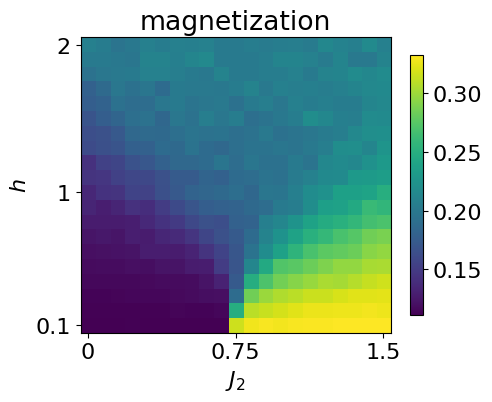

In [ ]:
plt.rcParams['font.size'] = 16
plt.figure(figsize=(5,5),dpi=100)

plt.imshow(jnp.rot90(jnp.mean(jnp.abs(jnp.mean(data*2-1, axis=-1)), axis=-1)))
plt.ylabel(r'$h$')
plt.xlabel(r'$J_2$')
plt.colorbar(shrink=0.675)
plt.title(r'magnetization')


y_tick_positions = [0,10,19]
y_tick_labels = ['2', '1', '0.1']
plt.yticks(y_tick_positions, y_tick_labels)

x_tick_positions = [0, 10, 20]
x_tick_labels = ['0', '0.75', '1.5']
plt.xticks(x_tick_positions, x_tick_labels)

plt.show()

We next cast the generated data into a **`QDisc.Dataset`** object, which provides a unified interface for handling quantum data within the QDisc pipeline.

To construct the dataset, the following information must be specified:
- the values of the tuning parameters,
- the type of quantum data,
- the dimension of the local Hilbert space,
- the values of the local states (for discrete data).


In [ ]:
from qdisc.dataset import Dataset

dataset = Dataset(data=data, thetas=[all_J2, all_h], data_type='discrete', local_dimension=2, local_states=jnp.array([0,1]))

To see in more details the class attributes and methods, we can simply use the python *help* function

In [ ]:
help(dataset)

Help on Dataset in module qdisc.dataset.core object:

class Dataset(builtins.object)
 |  Dataset(data: jax.Array, thetas: Sequence[jax.Array], data_type: str, local_dimension: int = 0, local_states: jax.Array = None)
 |
 |  Dataset(data: jax.Array, thetas: Sequence[jax.Array], data_type: str, local_dimension: int = 0, local_states: jax.Array = None)
 |
 |  Methods defined here:
 |
 |  __eq__(self, other)
 |      Return self==value.
 |
 |  __init__(self, data: jax.Array, thetas: Sequence[jax.Array], data_type: str, local_dimension: int = 0, local_states: jax.Array = None)
 |      Dataset class for learning representation of quantum data with VAE: vae4q.
 |
 |      Args:
 |
 |          data: jnp.ndarray of shape (num_values_theta1, ..., num_values_thetak, num_sample_per_params, input_size)
 |
 |          thetas: sequence of jnp.ndarray, each representing a parameter grid
 |
 |          data_type: str, one of ['discrete', 'continuous', 'hybrid', 'shadow']
 |
 |          local_dimension: i

## Learning a latent representation of the phase space

With the dataset in hand, we now learn a representation of the phase space. This is achieved using a **variational autoencoder ** trained to reconstruct the **conditional probabilities** of its input data (**cpVAE**)—here, spin configurations.

The VAE consists of two neural networks:
- an **encoder**, which here takes a spin configuration as input and outputs a mean $\mu_i$ and variance $\sigma_i$ defining a latent distribution $N(\mu_i,\sigma_i)$, from which a latent variable $z_i$ is sampled;
- a **decoder**, which reconstructs the conditional probabilities of the spin configuration given the latent variables $\mathbf{z}$.

Both the encoder and decoder are implemented using the **Flax** library.

Several model architectures are available in **`qdisc.nn`**. Given the simplicity of the present system, we use:
- a **convolutional neural network** for the encoder, and
- a **dense masked network** for the decoder.

One of the strengths of VAEs is their ability to **adaptively learn the effective dimensionality** of the latent space. In practice, this allows us to choose a latent dimension larger than what is physically expected and let the model determine how many latent variables are actually needed.

Here, we set `latent_dim = 5` while creating the encoder.

In [ ]:
from qdisc.nn import EncoderCNN2D, ARNNDense

encoder = EncoderCNN2D(latent_dim=5, conv_features = 4*N, dense_features = 4*N, num_conv_layers=3)
decoder = ARNNDense(num_layers=4, features=4*N)

Then we can simply create our VAE, from **qdisc.vae**, using the encoder and the decoder:

In [ ]:
from qdisc.vae import VAEmodel

myvae = VAEmodel(encoder=encoder, decoder=decoder)

The main object of this section is the trainer wrapper of the VAE, which is also implemented in **qdisc.VAE**. Its primary function is to train the model and compute the learned representation.
We can simply create it using our VAE and dataset:

In [ ]:
from qdisc.vae import VAETrainer

myvaetrainer = VAETrainer(model=myvae, dataset=dataset)

To train the model, we use the `.train()` method, specifying:
- a random key (for reproducibility),
- the number of training epochs,
- the loss hyperparameters $\alpha$, $\beta$, and $\gamma$.  
The training objective is defined as
$$
\mathcal{L}
=
\frac{1}{M}\sum_{m=1}^{M}
\mathbb{E}_q\!\left[\log p\!\left(x^{(m)} \mid z\right)\right]
-
\beta\,\mathrm{KL}\!\left[q\!\left(z \mid x^{(m)}\right)\,\|\,p(z)\right],
$$
where $M$ denotes the number of training samples $x^{(m)}$.

The first term promotes accurate probabilistic reconstruction of the input data.  
The second term is a regularization term that minimizes the Kullback–Leibler (KL) divergence between the latent posterior
$q(z_i) \sim \mathcal{N}(\mu_i, \sigma_i)$
and the standard normal prior $\mathcal{N}(0,1)$.

This regularization enforces the latent representation to remain close to an uninformed prior. The competition between the reconstruction and KL terms naturally leads to a sparse latent structure: only the minimum number of latent neurons required for faithful reconstruction deviate from the prior (referred to as **active neurons**), while the remaining ones collapse to the prior distribution (referred to as **passive neurons**). The hyperparameter $\beta$ controls the balance between these two contributions.

In addition, the library allows weighting the statistical correlations between latent neurons with the hyperparameter $\gamma$. This regularization can improve interpretability of the learned representation and, in some cases, simplify hyperparameter tuning. For details, we refer the reader to the original TCVAE paper (https://tinyurl.com/4r4pjkum).


Finally, for for hybrid data, the reconstruction loss itself is composed of two distinct terms. The hyperparameter $\alpha$ controls the relative weight between these contributions. For more details, see the corresponding paper or the example notebook illustrating on the FKM.


In [ ]:
#| eval: false

key = jax.random.PRNGKey(9812)
num_epochs = 30
myvaetrainer.train(num_epochs=num_epochs, batch_size=5000, beta=.5, gamma=5, key=key, printing_rate=4)

Start training...
epoch=0 step=0 loss=-164.0816877940576 recon=6.24122033277154
logvar=[ 0.02889643  0.06553731  0.08578867  0.07469489 -0.11742282]
epoch=4 step=0 loss=-166.50619210935855 recon=2.5268090385566655
logvar=[-0.02325771 -0.04400538 -0.04755984 -0.07347864 -5.17624178]
epoch=8 step=0 loss=-166.61826230319593 recon=2.1712226701840587
logvar=[ 5.55297007e-03  6.63575776e-03 -2.48477688e-02 -2.84092486e-03
 -6.03403115e+00]
epoch=12 step=0 loss=-166.85555225392096 recon=1.8898182191681325
logvar=[-0.02963185 -0.04852807 -0.0106527  -0.02541911 -6.26096837]
epoch=16 step=0 loss=-166.86486488722105 recon=1.850635718410977
logvar=[-0.01185585 -0.02171072 -0.03955803 -0.0346144  -6.35212598]
epoch=20 step=0 loss=-166.60456679846868 recon=2.00679015249195
logvar=[-0.00966867 -0.01969246 -0.01432308 -0.03597651 -6.8202739 ]
epoch=24 step=0 loss=-166.98446804170575 recon=1.6698276096480205
logvar=[-0.03217179 -0.03570768 -0.02405744 -0.02511504 -6.57563532]
epoch=28 step=0 loss=-166

In [ ]:
# this is just for nbdev test since the training was skipped (skip the training which is long on cpu but still need to init some quantities)
nbdev_test_mode = len(myvaetrainer.history_loss) == 0
if nbdev_test_mode:
    num_epochs = 1
    myvaetrainer.train(num_epochs=num_epochs, batch_size=10, beta=.5, gamma=5, key=jax.random.PRNGKey(0), printing_rate=4)

As suggested by simple observables such as the next-nearest-neighbour correlator, the phase space of this system can be fully characterized by a **single parameter**. We therefore expect only **one active latent neuron**, with the remaining ones collapsing to the prior.

To encourage this behavior, we use relatively large weights for the **KL divergence** and the **total correlation (TC)** terms. The TC regularization typically helps sparsify the latent representation, as an active latent variable tends to be weakly correlated with noise. When only one latent neuron is active, the TC term does not affect the learned representation but still helps suppress spurious correlations among passive neurons.


To have a better idea of what happened during the training, we can look at the reconstruction loss and the variances of the latent neurons using the `.plot_training()` method:

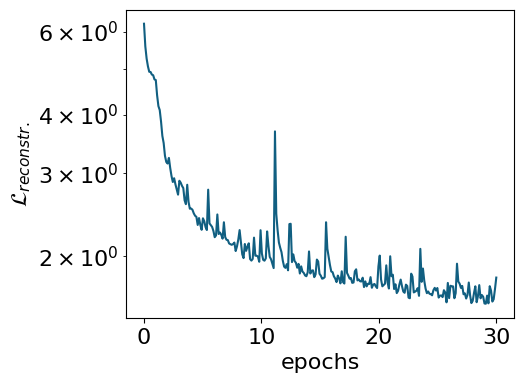

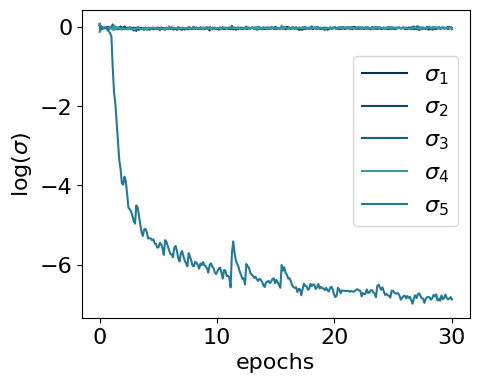

In [ ]:
myvaetrainer.plot_training(num_epochs = num_epochs)

We see that the model learns to encode information in only one active latent variable, as the variance of all the others collapses to one.

Now, it is interesting to look at the representation that the model has learned. This can be computed using the `compute_repr2d()` method and visualized using the `plot_repr2d()` method. Alternatively, both steps can be performed using the .compute_and_plot_repr2d() method, as demonstrated below:

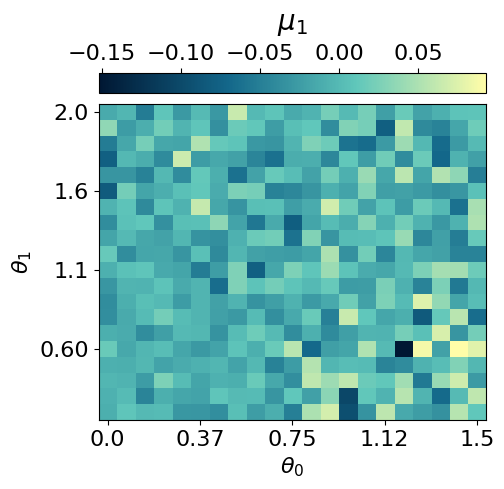

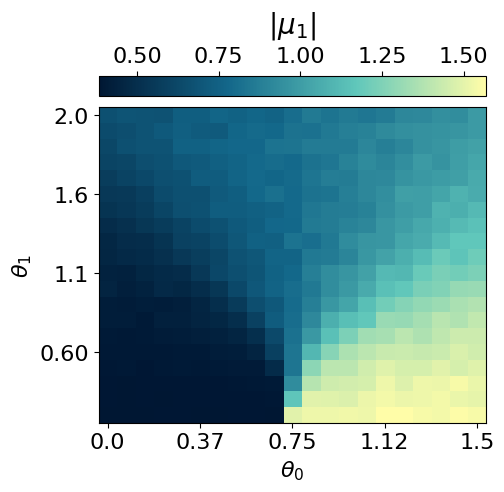

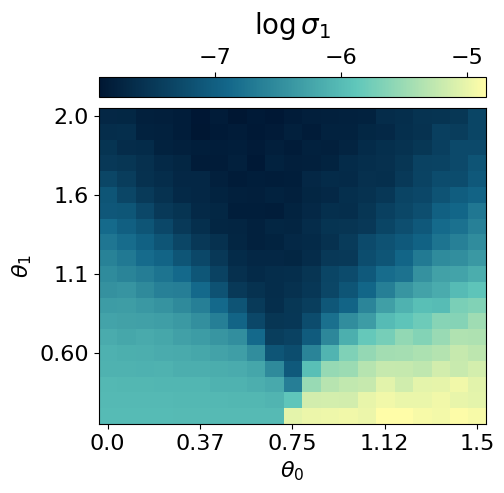

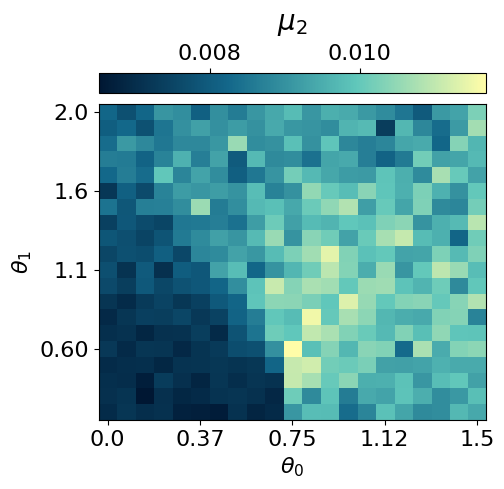

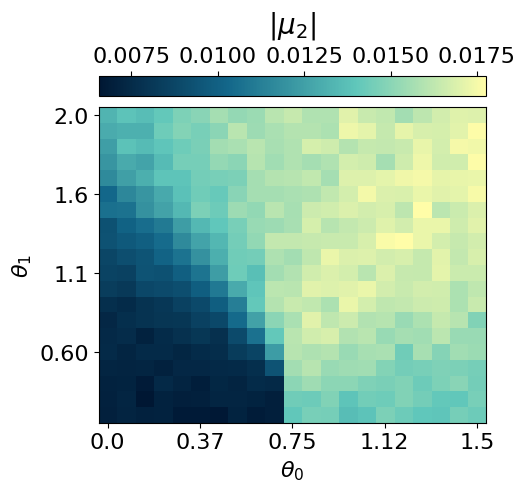

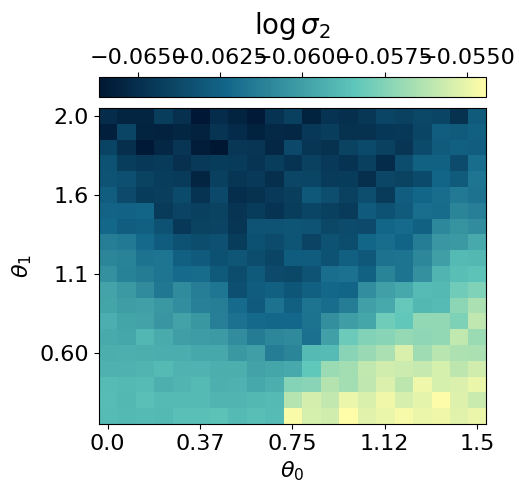

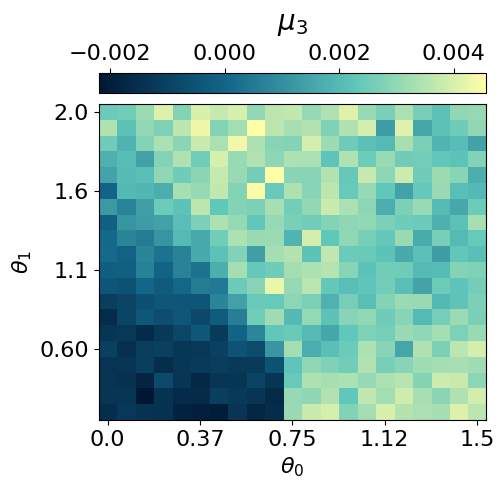

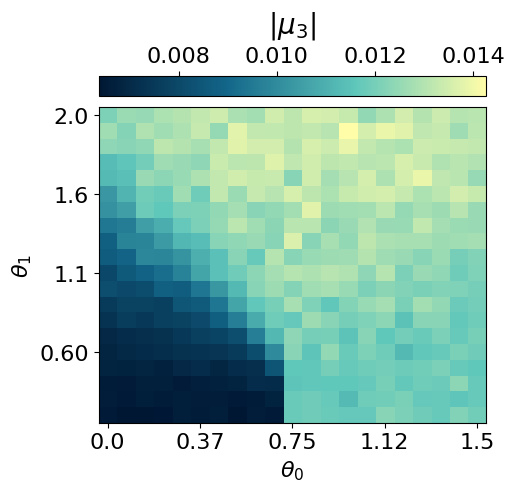

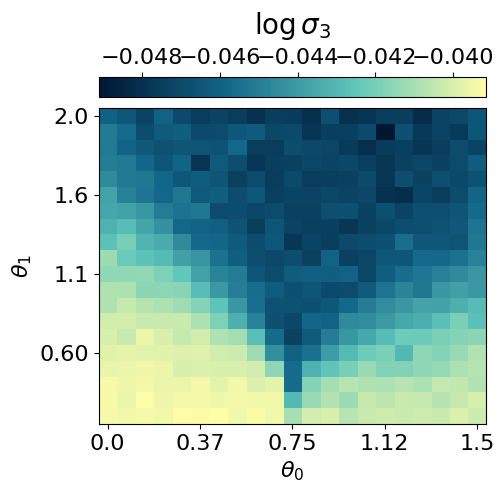

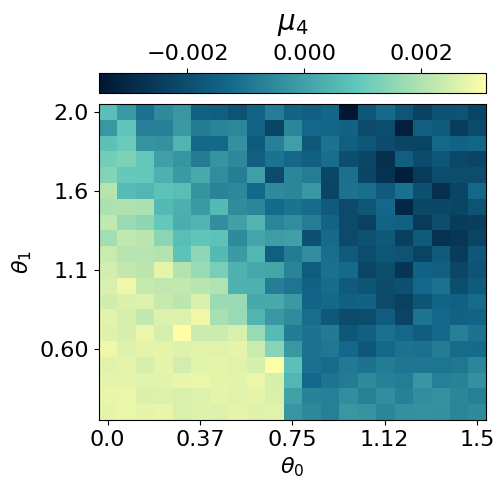

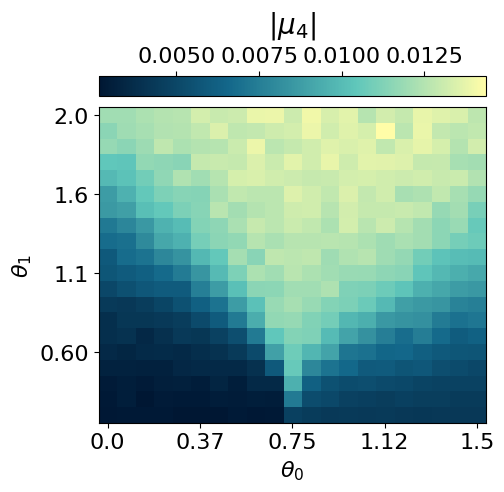

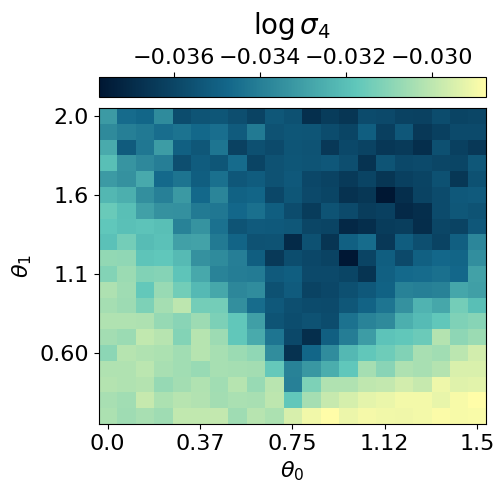

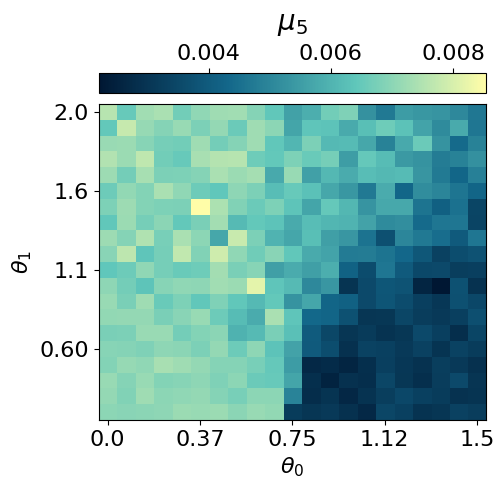

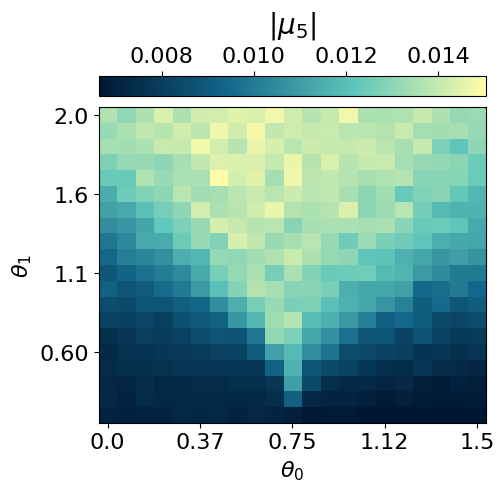

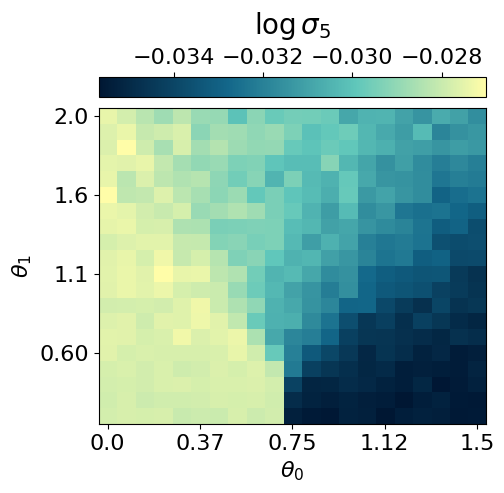

In [ ]:
#latvar = myvaetrainer.compute_repr2d(return_latvar = True) #this also update the attribute latvar of the object
#myvaetrainer.plot_repr2d()

## or one can do both by just calling
myvaetrainer.compute_and_plot_repr2d()

During training, the cpVAE reduces its reconstruction loss. However, a low reconstruction loss alone does not guarantee that the model faithfully approximates the true ground state. It is therefore essential to explicitly assess the **quality of the reconstructed physical observables**.

A common approach is to generate samples from the decoder and compute statistical estimates of selected observables. In our example, this is done by sampling spin configurations from the learned conditional distribution.

Below, we use the `.reconstruct_sample()` method to generate spin configurations at each point in parameter space and then compute the **average magnetization** across the full parameter range.

In [ ]:
reconstruct_sample = jnp.zeros_like(dataset.data)
key = jax.random.PRNGKey(2687)

for i in range(dataset.data.shape[0]):
  for j in range(dataset.data.shape[1]):
    subkey, key = jax.random.split(key)
    reconstruct_sample = reconstruct_sample.at[i,j].set(myvaetrainer.reconstruct_sample(dataset.data[i,j],subkey))


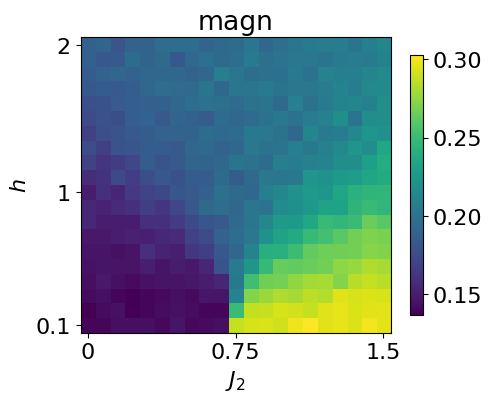

In [ ]:
plt.rcParams['font.size'] = 16
plt.figure(figsize=(5,5),dpi=100)

plt.imshow(jnp.rot90(jnp.mean(jnp.abs(jnp.mean(reconstruct_sample*2-1,axis=(-1))),axis=-1)))
plt.ylabel(r'$h$')
plt.xlabel(r'$J_2$')
plt.colorbar(shrink=0.675)
plt.title(r'magn')


y_tick_positions = [0,10,19]
y_tick_labels = ['2', '1', '0.1']
plt.yticks(y_tick_positions, y_tick_labels)

x_tick_positions = [0, 10, 20]
x_tick_labels = ['0', '0.75', '1.5']
plt.xticks(x_tick_positions, x_tick_labels)

plt.show()

This can be compared with the magnetization computed directly from the dataset.

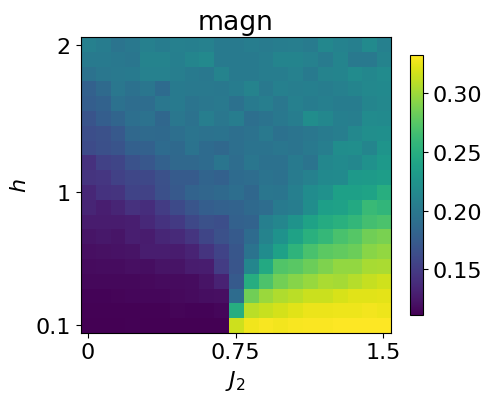

In [ ]:
plt.rcParams['font.size'] = 16
plt.figure(figsize=(5,5),dpi=100)

plt.imshow(jnp.rot90(jnp.mean(jnp.abs(jnp.mean(dataset.data*2-1,axis=(-1))),axis=-1)))
plt.ylabel(r'$h$')
plt.xlabel(r'$J_2$')
plt.colorbar(shrink=0.675)
plt.title(r'magn')


y_tick_positions = [0,10,19]
y_tick_labels = ['2', '1', '0.1']
plt.yticks(y_tick_positions, y_tick_labels)

x_tick_positions = [0, 10, 20]
x_tick_labels = ['0', '0.75', '1.5']
plt.xticks(x_tick_positions, x_tick_labels)

plt.show()
#quick comparaison without setting the same cbar
#given the patterns, should be ~1/9 for neel and ~1/3 for striped
#the apparent magnetization in the polarized phase is due to the fact that we make the average of the absolute magn. (all zero due to Z2 degene otherwise)

To save the results, the method `.get_data()` can be used. It returns a dictionary containing the training history, the optimized parameters of the VAE, the learned representation, ...

In [ ]:
all_data = myvaetrainer.get_data()
all_data.keys()

dict_keys(['params', 'history_loss', 'history_recon', 'history_logvar', 'latvar'])

Then I typically save using `pickle` as shown bellow

In [ ]:
## also add the data and the exact corr ##

all_data['corr_exact'] = data_exact['corr_gs']
all_data['corr2_exact'] = data_exact['corr2_gs']
all_data['data'] = dataset.data

In [ ]:
with open('J1J2_data_cpVAE2_QDisc.pkl', 'wb') as f:
    pickle.dump(all_data, f)

The loading is simply done using

In [ ]:
with open('J1J2_data_cpVAE2_QDisc.pkl', 'rb') as f:
    all_data = pickle.load(f)

## Clustering the latent representation

In this toy example, the different phases are easily visible in the learned latent representation. For more complex phase diagrams or higher-dimensional representations, however, identifying phase boundaries by eye can become challenging. To address this, **qdisc provides clustering tools** that operate directly on the learned latent space to automatically identify distinct phases.

The clustering algorithm currently implemented is a **Gaussian Mixture Model (GMM)**. The GMM is applied to a feature vector $X$ constructed as follows:
- the first component consists of the average values of the **active latent variable** across the parameter space;
- the (normalized) tuning parameters $\theta_i$ are appended to this vector.

Including the tuning parameters helps the GMM identify clusters with smoother and more well-defined boundaries. The relative contribution of the tuning parameters is controlled by a weighting parameter $\alpha$.

To use `qdisc.clustering.GaussianMixture()`, one must specify:
- the number of clusters (phases),
- the maximum number of iterations.

An optional initialization using $k$-means can be enabled by setting `init_params="kmeans"`.


GMM with n_components: 2


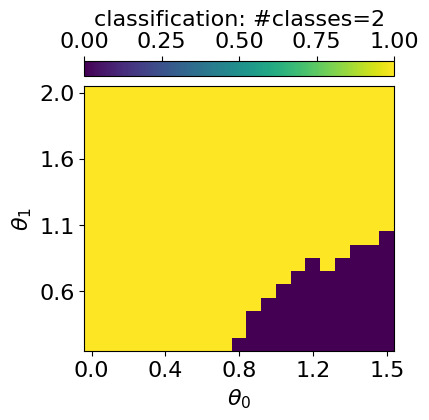

GMM with n_components: 3


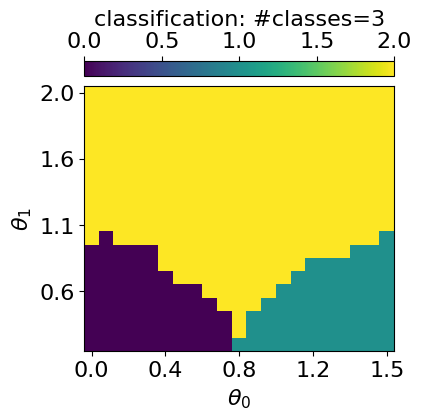

GMM with n_components: 4


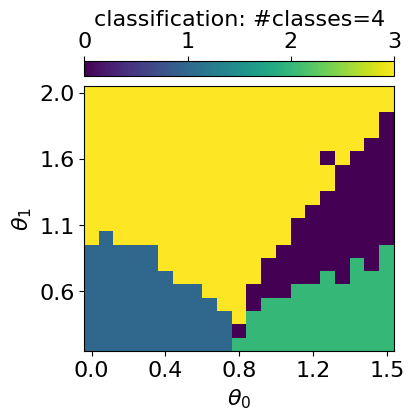

GMM with n_components: 5


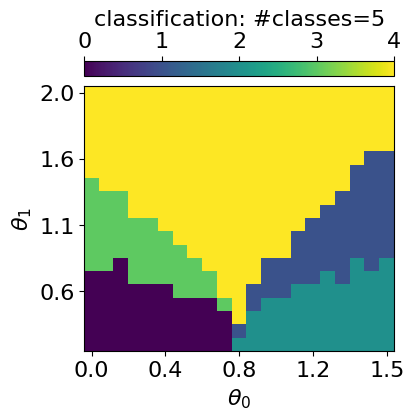

In [ ]:
from qdisc.clustering import GaussianMixture

## get the latent representation
#latvar = myvaetrainer.latvar
latvar = all_data['latvar']
data = all_data['data']
mu0abs = latvar['mu0_abs']
theta_pair = (1,0)#latvar['theta_pair']

#get the experimental parameters thetas to weight on the parameter space distance by alpha and have a smooter clustering
alpha = 0.001
theta1 = dataset.thetas[theta_pair[0]]
theta2 = dataset.thetas[theta_pair[1]]
theta1_norm = (theta1 - jnp.min(theta1)) / (jnp.max(theta1) - jnp.min(theta1))
theta2_norm = (theta2 - jnp.min(theta2)) / (jnp.max(theta2) - jnp.min(theta2))

#vector to perform the GMM one
X = jnp.array([mu0abs.reshape(-1), alpha*jnp.tile(theta1_norm[:,None], reps=(jnp.size(theta2_norm),)).reshape(-1), alpha*jnp.tile(theta2_norm[None, :], reps=(jnp.size(theta1_norm),)).reshape(-1)]).transpose()


for n_components in [2,3,4,5]:

    print('GMM with n_components: {}'.format(n_components))

    clusterer = GaussianMixture(
                                n_components=n_components,
                                max_iter=500,
                                init_params="kmeans"
                            )

    clusterer.fit(X, key=jax.random.PRNGKey(4362))



    classes = clusterer.predict(X).reshape((jnp.size(theta1),jnp.size(theta2)))

    final_classes = jnp.zeros((jnp.size(theta1),jnp.size(theta2)))
    for i in range(jnp.size(theta1)):
      for j in range(jnp.size(theta2)):
        v, c = jnp.unique_counts(classes[i,j])
        final_classes = final_classes.at[i,j].set(v[jnp.argmax(c)])



    fig_shape = (len(theta1)/5, len(theta2)/5)

    plt.rcParams['font.size'] = 16
    plt.figure(figsize=fig_shape,dpi=100)

    plt.imshow(jnp.flipud(final_classes), aspect='auto')
    cbar = plt.colorbar(orientation="horizontal", pad=0.03, location="top")
    cbar.set_label(r'classification: #classes={}'.format(n_components))


    plt.ylabel(r'$\theta_{}$'.format(theta_pair[0]))
    plt.xlabel(r'$\theta_{}$'.format(theta_pair[1]))
    plt.yticks([i for i in range(0,len(theta1),len(theta1)//4)], [str(theta1[len(theta1)-i])[:3] for i in range(0,len(theta1),len(theta1)//4)])
    plt.xticks([i for i in range(0,len(theta2)+1,len(theta2)//4)], [str(theta2[i])[:3] for i in range(1,len(theta2)+1,len(theta2)//4)])

    plt.show()

To find the optimal number of classes, qdisc.clustering provide the `select_n_components()` function which can be used as shown below

In [ ]:
from qdisc.clustering import select_n_components
## Can also compute some metrics to evaluate the optimal number of class

ks = range(2, 7)  # ranges of n_components tested
results = select_n_components(X, ks, n_init=5, max_iter=500, random_seed=2546)

# collect bic/aic/loglikelihood
bics = jnp.array([results[k]['metrics']['bic'] for k in ks])
aics = jnp.array([results[k]['metrics']['aic'] for k in ks])
avg_lls = jnp.array([results[k]['metrics']['avg_log_likelihood'] for k in ks])

# K that minimizes BIC/AIC
best_k_bic = ks[jnp.argmin(bics)]
best_k_aic = ks[jnp.argmin(aics)]
print("Best K (BIC):", best_k_bic, "Best K (AIC):", best_k_aic)

#3 is indeed the best (neel, pola, striped), the fourth one is a phase boundary (can also be interesting)

Trying K=2
Trying K=3
Trying K=4
Trying K=5
Trying K=6
Best K (BIC): 3 Best K (AIC): 5


results GMM n_components: 2
BIC: -9671.737805761446
AIC: -9748.502645275717
avg_log_likelihood: 11.650598387232998
results GMM n_components: 3
BIC: -9780.154057315114
AIC: -9897.321443942159
avg_log_likelihood: 11.85157314755019
results GMM n_components: 4
BIC: -9734.804057052224
AIC: -9892.373990792044
avg_log_likelihood: 11.869492846181007
results GMM n_components: 5
BIC: -9708.534831369328
AIC: -9906.507312221922
avg_log_likelihood: 11.910127752645145
results GMM n_components: 6
BIC: -9653.219566575384
AIC: -9891.594594540751
avg_log_likelihood: 11.916184041119942


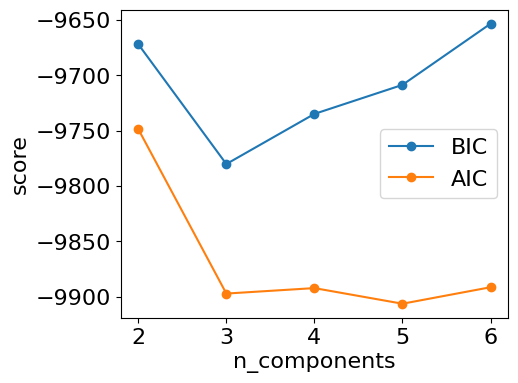

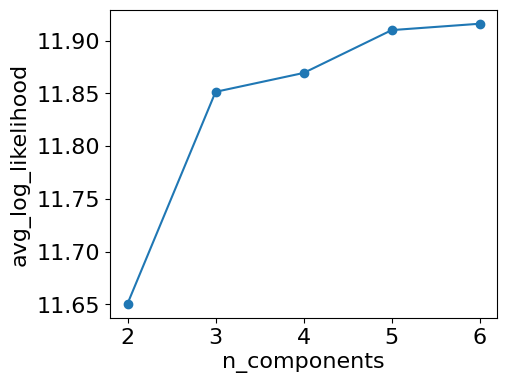

In [ ]:
## plot of each metrics

from matplotlib import pyplot as plt


for i, k in enumerate(ks):
  print('results GMM n_components: {}'.format(k))
  print('BIC: {}'.format(bics[i]))
  print('AIC: {}'.format(aics[i]))
  print('avg_log_likelihood: {}'.format(avg_lls[i]))



plt.rcParams['font.size'] = 16
plt.figure(figsize=(5,4),dpi=100)

plt.plot(ks, bics, 'o-', label='BIC')
plt.plot(ks, aics, 'o-', label='AIC')
#plt.plot(ks, avg_lls, 'o-', label='avg_log_likelihood')

plt.xlabel('n_components')
plt.ylabel('score')
plt.legend()


plt.rcParams['font.size'] = 16
plt.figure(figsize=(5,4),dpi=100)

plt.plot(ks, avg_lls, 'o-', label='avg_log_likelihood')
plt.xlabel('n_components')
plt.ylabel('avg_log_likelihood')

plt.show()
#3 also leads to a big increase og log_likelihood

## Symbolic regression

Finally, we introduce the **symbolic regression (SR)** tools implemented in qdisc. These methods aim to identify **compact analytic descriptors** of latent clusters, which can often be interpreted as candidate order parameters.

The main entry point is the `qdisc.sr.SymbolicRegression()` class. It is initialized by specifying the following attributes:

- the dataset (an instance of `qdisc.Dataset`),
- the index (in $\theta$-space) of the cluster to be analyzed,
- the objective used to define the loss / fitness function:
  - a **classification objective** (SR1),
  - a **boundary-matching objective** in $x$-space (SR2),
  - a **boundary-matching objective** in $\theta$-space (SR3),
- for SR1, the indices of data points labeled as outside the cluster,
- For SR2 and SR3, the VAE should also be given with the index of the latent variable where the cluster appear
- for SR3, the method used to construct the projector $v_k$ (currently `'delta'` or `'cp'`).

In addition, the **search space** of the symbolic expression must be specified. qdisc currently supports two options:
- a **two-body correlator ansatz**,
  $$
  f(x) = \sum_{i,j>i} \alpha_{i,j}\, x_i x_j + b,
  $$
- a more expressive search space based on **genetic programming**. By setting the option to `'genetic'`, qdisc interfaces with **PySR**. For further details, we refer the reader to the PySR documentation:
  $$
  \texttt{https://github.com/MilesCranmer/PySR}
  $$

In the following, we use qdisc to identify a symbolic expression characterizing the **Néel phase**, employing the two-body correlator ansatz and comparing the different symbolic regression objectives.


In [ ]:
## reload the necessary objects if needed
from qdisc.nn import EncoderCNN2D, ARNNDense
from qdisc.vae import VAEmodel
from qdisc.sr import SymbolicRegression
from qdisc.sr import spearman_rho
from qdisc.sr import auc_from_scores_labels

N = 9
encoder = EncoderCNN2D(latent_dim=5, conv_features = 4*N, dense_features = 4*N, num_conv_layers=3)
decoder = ARNNDense(num_layers=4, features=4*N)

VAE_model = VAEmodel(encoder=encoder, decoder=decoder)
VAE_params = all_data['params']
latvar = all_data['latvar']

### Neel

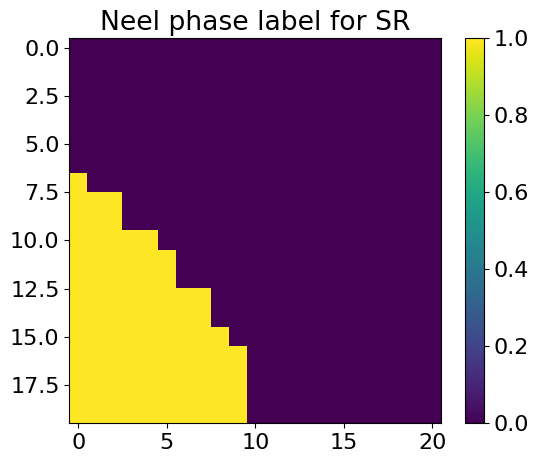

In [ ]:
## we first specify the indexe of the cluster ##
# could use the GMM results, in this toy example, can also just set a threshold
mu0abs = latvar['mu0_abs']
threshold = 0.5
## !!! the idx are related to dataset thetas order, if latvar were computed using (1,0) order (as before), need to transpose !!!
cluster_idx_in_neel = jnp.argwhere(mu0abs.transpose()<threshold)
#VAE_model = myvaetrainer.model
#VAE_params = myvaetrainer.state.params


# also compute a label array (used later to compute the auc)
labels_neel = jnp.zeros_like(jnp.mean(dataset.data, axis=(-1,-2)))
for id in cluster_idx_in_neel:
  labels_neel = labels_neel.at[id[0],id[1]].set(1)
labels_neel = labels_neel[:10,:].reshape(-1)


plt.rcParams['font.size'] = 16
plt.figure(figsize=(6,5),dpi=100)

plt.imshow(jnp.flipud(mu0abs<threshold), aspect='auto')
plt.colorbar()
plt.title(r'Neel phase label for SR')
plt.show()

In [ ]:
## this is just for development with nbdev (it tests the notebook and training take too much time so it skip it but in that case, for it not to fail, need to have non empty idx ##
if nbdev_test_mode: 
    cluster_idx_in_neel = jnp.argwhere(data_exact['corr2_gs']>5)

After initializing a `SymbolicRegression` object, the symbolic search can be launched by simply calling the `.train()` method.

For the two-body correlator ansatz, QDisc provides visualization utilities to help interpret the learned expression. In particular, the `.plot_alpha()` method displays the learned coefficients $\alpha_{i,j}$, given the specified topology of the quantum system.

Once a symbolic expression $f(x)$ is obtained, its predictions can be computed and visualized using the `.compute_and_plot_prediction()` method.

Finally, to quantify the quality of the symbolic descriptor $f(x)$, one can compute the **Spearman correlation coefficient** between the model predictions and a reference physical observable (here, the nearest-neighbour correlator).


### Start preparing the dataset ###
### Dataset prepared, start the trainnig ###
### Training finished ###
  message: CONVERGENCE: NORM OF PROJECTED GRADIENT <= PGTOL
  success: True
   status: 0
      fun: 0.3095923514569056
        x: [ 2.275e-01  4.329e-02 ...  1.947e-01  3.512e-01]
      nit: 23
      jac: [ 2.898e-06 -3.419e-06 ...  3.308e-06 -1.316e-06]
     nfev: 999
     njev: 27
 hess_inv: <36x36 LbfgsInvHessProduct with dtype=float64>


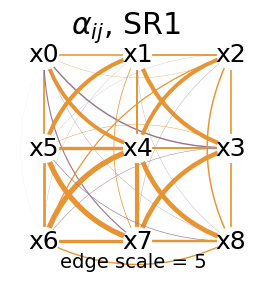

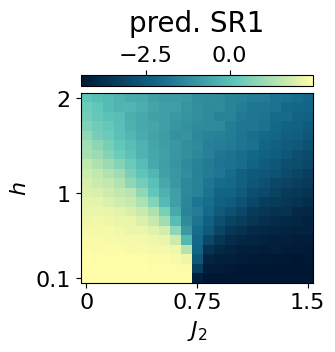

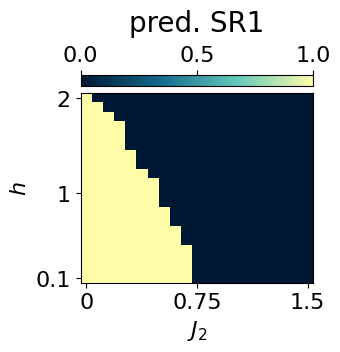

spearman between pred and exact corr:  0.97756845
auc:  0.9991902014373922


In [ ]:
## we then parform SR1 on the neel phase ##
from qdisc.sr import SymbolicRegression
from qdisc.sr import spearman_rho
from qdisc.sr import auc_from_scores_labels

mySR = SymbolicRegression(dataset, cluster_idx_in_neel, objective='SR1', search_space = "2_body_correlator" )
key = jax.random.PRNGKey(3246)
res = mySR.train(key, dataset_size=2000)

## plot the alpha ##
topology = [[0,1,2],[5,4,3],[6,7,8]]
mySR.plot_alpha(topology=topology, edge_scale=5, name='SR1')


## plot the prediction ##
p = mySR.compute_and_plot_prediction(name='SR1')
_ = mySR.compute_and_plot_prediction(name='SR1', class_pred=True)

## containers to safe the results
all_alpha_neel = {}
all_alpha_neel['SR1'] = mySR.model.alpha
all_prediction_fx_neel = {}
all_prediction_fx_neel['SR1'] = p

## compute the spearman ##
#only on the left part of the parameter space where the Neel phase is
a = p[:,:10].transpose().reshape(-1)
c = data_exact['corr_gs'][:10,:].reshape(-1)
s = jnp.abs(spearman_rho(a, c))

print('spearman between pred and exact corr: ', s)

## compute the auc ##
scores = p.transpose()[:10,:].reshape(-1)
#for classification, we should use the final classification for the score: p>0. But it is unfair with the other SR which are not binary.
auc = auc_from_scores_labels(scores, labels_neel)

print('auc: ', auc)

### Start preparing the dataset ###
### Dataset prepared, start the trainnig ###
### Training finished ###
  message: CONVERGENCE: RELATIVE REDUCTION OF F <= FACTR*EPSMCH
  success: True
   status: 0
      fun: 3384.656136473002
        x: [-8.901e-02  1.057e-01 ... -1.334e-01  1.815e+00]
      nit: 38
      jac: [ 0.000e+00 -1.364e-03 ...  6.548e-03 -1.955e-03]
     nfev: 1591
     njev: 43
 hess_inv: <36x36 LbfgsInvHessProduct with dtype=float64>


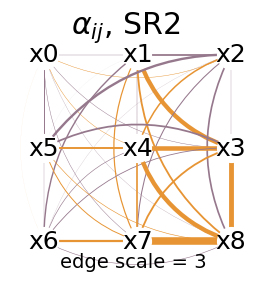

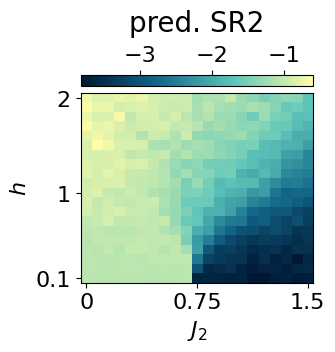

spearman between pred and exact corr:  0.20214355
auc:  0.39093025609879534


In [ ]:
## same but with the SR2 objective ##
mySR = SymbolicRegression(dataset,
                          cluster_idx_in_neel,
                          objective='SR2',
                          idx_mu_cluster=latvar['id_lat'][0],
                          VAE_model=VAE_model,
                          VAE_params=VAE_params,
                          mu_cluster = mu0abs.transpose())

key = jax.random.PRNGKey(456)
res = mySR.train(key)

## plot the alpha ##
topology = [[0,1,2],[5,4,3],[6,7,8]]
mySR.plot_alpha(topology=topology, edge_scale=3, name='SR2')


## plot the prediction ##
p = mySR.compute_and_plot_prediction(name='SR2')

all_alpha_neel['SR2'] = mySR.model.alpha
all_prediction_fx_neel['SR2'] = p


## compute the spearman ##
a = p[:,:10].transpose().reshape(-1)
c = data_exact['corr_gs'][:10,:].reshape(-1)
s = jnp.abs(spearman_rho(a, c))

print('spearman between pred and exact corr: ', s)


## compute the auc ##
scores = p.transpose()[:10,:].reshape(-1)
auc = auc_from_scores_labels(scores, labels_neel)

print('auc: ', auc)

### Start preparing the dataset ###
small MLP training started...
step: 0, loss: 1.3323418013592538
step: 200, loss: 0.02766891116466986
step: 400, loss: 0.02092254942255096
step: 600, loss: 0.01657477318198375
step: 800, loss: 0.011717969955719856
step: 1000, loss: 0.008344421086105057
step: 1200, loss: 0.006762370072712967
step: 1400, loss: 0.005949197680164526
step: 1600, loss: 0.005462314303883701
step: 1800, loss: 0.005101367207964521
small MLP training finished!


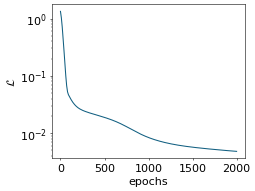

### Dataset prepared, start the trainnig ###
### Training finished ###
  message: CONVERGENCE: NORM OF PROJECTED GRADIENT <= PGTOL
  success: True
   status: 0
      fun: 4.2634377379160906e-05
        x: [ 1.936e-01 -2.103e-01 ...  1.699e-01  1.966e-01]
      nit: 1
      jac: [-3.430e-06 -6.442e-07 ...  3.875e-06 -4.088e-06]
     nfev: 74
     njev: 2
 hess_inv: <36x36 LbfgsInvHessProduct with dtype=float64>


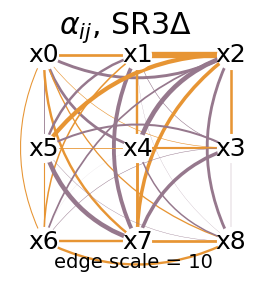

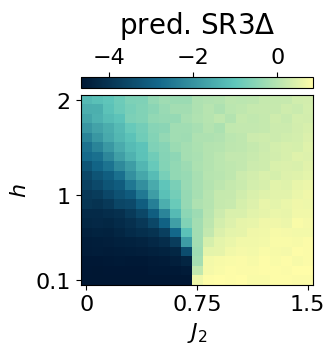

spearman between pred and exact corr:  0.9952884
auc:  0.9994938758983702


In [ ]:
## same but with the SR3 delta objective ##
mySR = SymbolicRegression(dataset, cluster_idx_in_neel, objective='SR3',
                                type_of_vk = 'delta',
                                idx_mu_cluster=latvar['id_lat'][0],
                                VAE_model=VAE_model,
                                VAE_params=VAE_params,
                                mu_cluster = mu0abs.transpose())
key = jax.random.PRNGKey(4352)
res = mySR.train(key)

## plot the alpha ##
mySR.plot_alpha(topology=topology, edge_scale=10, name=r'SR3$\Delta$')

## plot the prediction ##
p = mySR.compute_and_plot_prediction(name=r'SR3$\Delta$')

all_alpha_neel['SR3delta'] = mySR.model.alpha
all_prediction_fx_neel['SR3delta'] = p


## compute the spearman ##
a = p[:,:10].transpose().reshape(-1)
c = data_exact['corr_gs'][:10,:].reshape(-1)
s = jnp.abs(spearman_rho(a, c))

print('spearman between pred and exact corr: ', s)


## compute the auc ##
scores = p.transpose()[:10,:].reshape(-1)
auc = auc_from_scores_labels(scores, labels_neel)

print('auc: ', 1-auc)#grad matching doesnt impose <0 or >0 in the cluster, can just set what it has learned

### Start preparing the dataset ###
small MLP training started...
step: 0, loss: 0.8097712053950781
step: 200, loss: 0.02489800366754557
step: 400, loss: 0.019853631165409932
step: 600, loss: 0.014326587863111365
step: 800, loss: 0.006815097703099412
step: 1000, loss: 0.005358719587363029
step: 1200, loss: 0.004851576046314724
step: 1400, loss: 0.004468891983309704
step: 1600, loss: 0.004194644415257441
step: 1800, loss: 0.004005591705813629
small MLP training finished!


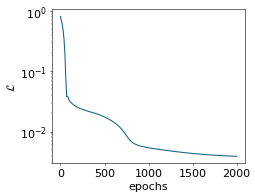

### Dataset prepared, start the trainnig ###
### Training finished ###
  message: CONVERGENCE: NORM OF PROJECTED GRADIENT <= PGTOL
  success: True
   status: 0
      fun: 3.0767273977635384e-05
        x: [ 6.443e-02  2.206e-01 ...  2.517e-01  9.649e-02]
      nit: 1
      jac: [-5.901e-08 -3.003e-06 ... -5.704e-06  7.864e-06]
     nfev: 74
     njev: 2
 hess_inv: <36x36 LbfgsInvHessProduct with dtype=float64>


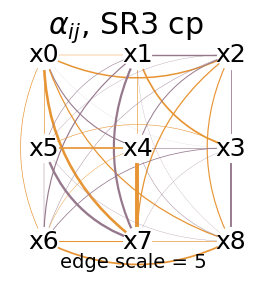

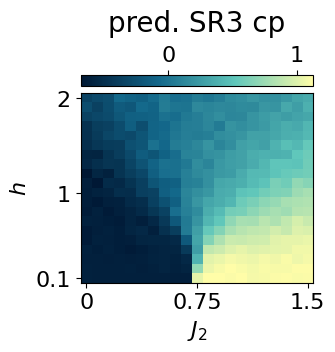

spearman between pred and exact corr:  0.9118053
auc:  0.9926105881162061


In [ ]:
## same but with the SR3 cp objective ##
mySR = SymbolicRegression(dataset, cluster_idx_in_neel, objective='SR3',
                                type_of_vk = 'cp',
                                idx_mu_cluster=latvar['id_lat'][0],
                                VAE_model=VAE_model,
                                VAE_params=VAE_params,
                                mu_cluster = mu0abs.transpose())
key = jax.random.PRNGKey(78324)
res = mySR.train(key)

## plot the alpha ##
mySR.plot_alpha(topology=topology, edge_scale=5, name='SR3 cp')

## plot the prediction ##
p = mySR.compute_and_plot_prediction(name='SR3 cp')

all_alpha_neel['SR3cp'] = mySR.model.alpha
all_prediction_fx_neel['SR3cp'] = p


## compute the spearman ##
a = p[:,:10].transpose().reshape(-1)#.reshape(10,-1)#all_prediction_neel_SR1[:,:10,:].reshape(10,-1)
c = data_exact['corr_gs'][:10,:].reshape(-1)
s = jnp.abs(spearman_rho(a, c))

print('spearman between pred and exact corr: ', s)


## compute the auc ##
scores = p.transpose()[:10,:].reshape(-1)
auc = auc_from_scores_labels(scores, labels_neel)

print('auc: ', 1-auc)

The symbolic expressions obtained using qdisc are all able to **characterize the Néel phase**. In particular, the expression derived using the **SR1 objective** is especially insightful, as its structure naturally reflects the **topology and interaction of the system**.

An example of `qdisc.sr.SymbolicRegression()` using the **genetic search space** is available in the Rydberg example.

Using the **two-body correlator ansatz**, qdisc also allows further simplification of the learned coefficients $\alpha_{ij}$ into a **compact symbolic expression** by calling **PySR**. This can be done via the `.reduce_alpha()` method. An example of this workflow is presented in the cluster Ising example.


### Striped

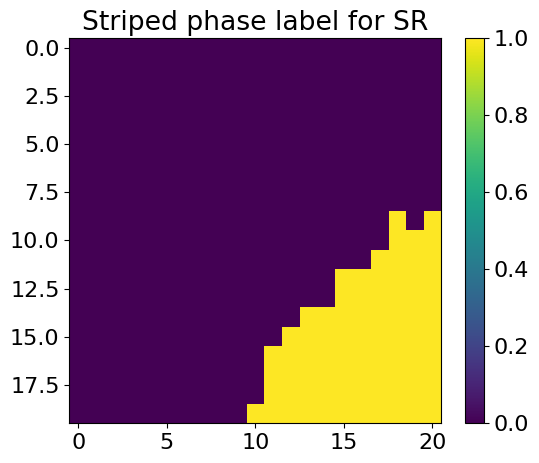

In [ ]:
threshold = 1.2
cluster_idx_in_striped = jnp.argwhere(mu0abs.transpose()>threshold)

labels_striped = jnp.zeros_like(jnp.mean(dataset.data, axis=(-1,-2)))
for id in cluster_idx_in_striped:
  labels_striped = labels_striped.at[id[0],id[1]].set(1)
labels_striped = labels_striped[10:,:].reshape(-1)


plt.rcParams['font.size'] = 16
plt.figure(figsize=(6,5),dpi=100)

plt.imshow(jnp.flipud(mu0abs>threshold), aspect='auto')
plt.colorbar()
plt.title(r'Striped phase label for SR')
plt.show()

In [ ]:
## this is just for development with nbdev (it tests the notebook and training take too much time so it skip it but in that case, for it not to fail, need to have non empty idx ##
if nbdev_test_mode: 
    cluster_idx_in_striped = jnp.argwhere(data_exact['corr2_gs']<-5)

### Start preparing the dataset ###
### Dataset prepared, start the trainnig ###
### Training finished ###
  message: CONVERGENCE: NORM OF PROJECTED GRADIENT <= PGTOL
  success: True
   status: 0
      fun: 0.34408257173622087
        x: [ 4.487e-01  2.722e-01 ...  3.491e-01  5.999e-01]
      nit: 27
      jac: [ 1.121e-06  1.221e-07 ...  3.775e-07  9.437e-07]
     nfev: 1110
     njev: 30
 hess_inv: <36x36 LbfgsInvHessProduct with dtype=float64>


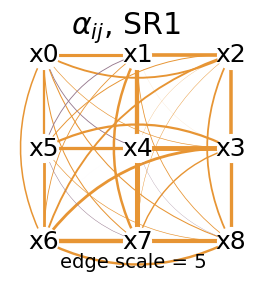

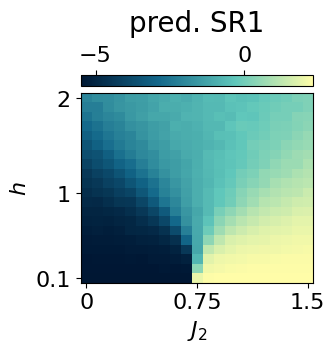

spearman between pred and exact corr:  0.9884032
auc:  0.9993715773408742


In [ ]:
## we then parform SR1 ##
mySR = SymbolicRegression(dataset, cluster_idx_in_striped, objective='SR1', search_space = "2_body_correlator" )
key = jax.random.PRNGKey(451)
res = mySR.train(key, dataset_size=2000)

## plot the alpha ##
topology = [[0,1,2],[5,4,3],[6,7,8]]
mySR.plot_alpha(topology=topology, edge_scale=5, name='SR1')

## plot the prediction ##
p = mySR.compute_and_plot_prediction(name='SR1')
#_ = mySR.compute_and_plot_prediction(name='SR1', class_pred=True)

## containers to save the results
all_alpha_striped = {}
all_alpha_striped['SR1'] = mySR.model.alpha
all_prediction_fx_striped = {}
all_prediction_fx_striped['SR1'] = p


## compute the spearman ##
#only on the left part of the parameter space where the Neel phase is
a = p[:,10:].transpose().reshape(-1)
c = data_exact['corr2_gs'][10:,:].reshape(-1)
s = jnp.abs(spearman_rho(a, c))

print('spearman between pred and exact corr: ', s)


## compute the auc ##
scores = p.transpose()[10:,:].reshape(-1)
auc = auc_from_scores_labels(scores, labels_striped)

print('auc: ', auc)

### Start preparing the dataset ###
### Dataset prepared, start the trainnig ###
### Training finished ###
  message: CONVERGENCE: RELATIVE REDUCTION OF F <= FACTR*EPSMCH
  success: True
   status: 0
      fun: 6232.258952393671
        x: [ 2.108e-01  1.685e-01 ... -6.494e-01  4.196e+00]
      nit: 68
      jac: [-3.347e-02  5.002e-03 ... -4.638e-03 -9.823e-03]
     nfev: 2701
     njev: 73
 hess_inv: <36x36 LbfgsInvHessProduct with dtype=float64>


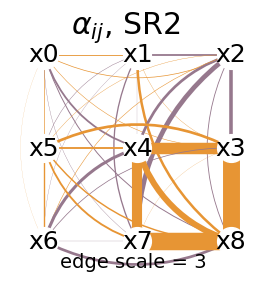

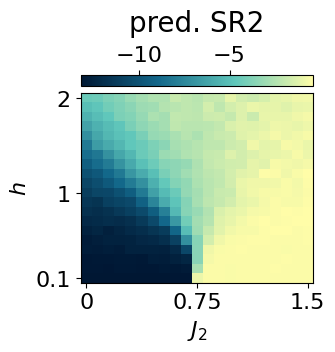

spearman between pred and exact corr:  0.88788086
auc:  0.973875572313493


In [ ]:
## same but with the SR2 objective ##
mySR = SymbolicRegression(dataset,
                          cluster_idx_in_striped,
                          objective='SR2',
                          idx_mu_cluster=latvar['id_lat'][0],
                          VAE_model=VAE_model,
                          VAE_params=VAE_params,
                          mu_cluster = mu0abs.transpose())

key = jax.random.PRNGKey(4352)
res = mySR.train(key)

## plot the alpha ##
topology = [[0,1,2],[5,4,3],[6,7,8]]
mySR.plot_alpha(topology=topology, edge_scale=3, name='SR2')


## plot the prediction ##
p = mySR.compute_and_plot_prediction(name='SR2')


all_alpha_striped['SR2'] = mySR.model.alpha
all_prediction_fx_striped['SR2'] = p

## compute the spearman ##
a = p[:,10:].transpose().reshape(-1)
c = data_exact['corr2_gs'][10:,:].reshape(-1)
s = jnp.abs(spearman_rho(a, c))

print('spearman between pred and exact corr: ', s)

## compute the auc ##
scores = p.transpose()[10:,:].reshape(-1)
auc = auc_from_scores_labels(scores, labels_striped)

print('auc: ', auc)

### Start preparing the dataset ###
small MLP training started...
step: 0, loss: 0.8379740018775372
step: 200, loss: 0.024739150455155158
step: 400, loss: 0.014466918890296923
step: 600, loss: 0.00975190890383155
step: 800, loss: 0.006796013795945494
step: 1000, loss: 0.0056436228279039225
step: 1200, loss: 0.004974692340699041
step: 1400, loss: 0.004572283159753465
step: 1600, loss: 0.004261206090227656
step: 1800, loss: 0.004038442828482392
small MLP training finished!


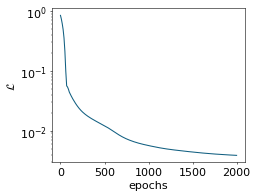

### Dataset prepared, start the trainnig ###
### Training finished ###
  message: CONVERGENCE: NORM OF PROJECTED GRADIENT <= PGTOL
  success: True
   status: 0
      fun: 4.797356381271416e-05
        x: [ 1.577e-01 -3.728e-01 ... -2.039e-01  1.128e-01]
      nit: 1
      jac: [-1.688e-07 -1.654e-06 ... -1.006e-06 -6.175e-07]
     nfev: 74
     njev: 2
 hess_inv: <36x36 LbfgsInvHessProduct with dtype=float64>


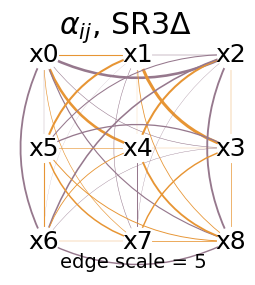

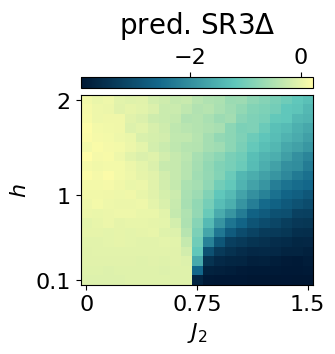

spearman between pred and exact corr:  0.9958019
auc:  0.999281802675285


In [ ]:
## same but with the SR3 delta objective ##
mySR = SymbolicRegression(dataset, cluster_idx_in_striped, objective='SR3',
                                type_of_vk = 'delta',
                                idx_mu_cluster=latvar['id_lat'][0],
                                VAE_model=VAE_model,
                                VAE_params=VAE_params,
                                mu_cluster = mu0abs.transpose())
key = jax.random.PRNGKey(43)
res = mySR.train(key)

## plot the alpha ##
mySR.plot_alpha(topology=topology, edge_scale=5, name=r'SR3$\Delta$')

## plot the prediction ##
p = mySR.compute_and_plot_prediction(name=r'SR3$\Delta$')

all_alpha_striped['SR3delta'] = mySR.model.alpha
all_prediction_fx_striped['SR3delta'] = p

## compute the spearman ##
a = p[:,10:].transpose().reshape(-1)
c = data_exact['corr2_gs'][10:,:].reshape(-1)
s = jnp.abs(spearman_rho(a, c))

print('spearman between pred and exact corr: ', s)

## compute the auc ##
scores = p.transpose()[10:,:].reshape(-1)
auc = auc_from_scores_labels(scores, labels_striped)

print('auc: ', 1-auc)

### Start preparing the dataset ###
small MLP training started...
step: 0, loss: 1.0159905974775323
step: 200, loss: 0.02400304088490106
step: 400, loss: 0.01693802827362819
step: 600, loss: 0.008863654527734466
step: 800, loss: 0.006959753998263992
step: 1000, loss: 0.006045763865856662
step: 1200, loss: 0.005430398594056031
step: 1400, loss: 0.004972847239540341
step: 1600, loss: 0.004649842350849804
step: 1800, loss: 0.004437556237735732
small MLP training finished!


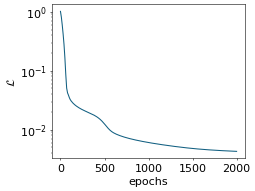

### Dataset prepared, start the trainnig ###
### Training finished ###
  message: CONVERGENCE: NORM OF PROJECTED GRADIENT <= PGTOL
  success: True
   status: 0
      fun: 3.420804468017116e-05
        x: [ 3.097e-02 -7.188e-02 ...  4.103e-01 -8.968e-02]
      nit: 2
      jac: [-4.809e-07 -6.340e-07 ...  9.004e-07  2.162e-06]
     nfev: 111
     njev: 3
 hess_inv: <36x36 LbfgsInvHessProduct with dtype=float64>


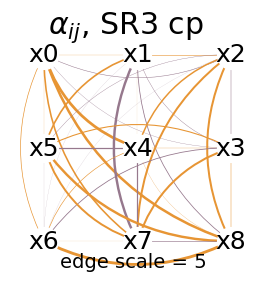

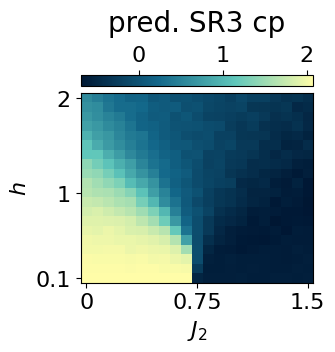

spearman between pred and exact corr:  0.90589815
auc:  0.9851871801777539


In [ ]:
## same but with the SR3 cp objective ##
mySR = SymbolicRegression(dataset, cluster_idx_in_striped, objective='SR3',
                                type_of_vk = 'cp',
                                idx_mu_cluster=latvar['id_lat'][0],
                                VAE_model=VAE_model,
                                VAE_params=VAE_params,
                                mu_cluster = mu0abs.transpose())
key = jax.random.PRNGKey(11122)
model = mySR.train(key)

## plot the alpha ##
mySR.plot_alpha(topology=topology, edge_scale=5, name='SR3 cp')

## plot the prediction ##
p = mySR.compute_and_plot_prediction(name='SR3 cp')

all_alpha_striped['SR3cp'] = mySR.model.alpha
all_prediction_fx_striped['SR3cp'] = p

## compute the spearman ##
a = p[:,10:].transpose().reshape(-1)
c = data_exact['corr2_gs'][10:,:].reshape(-1)
s = jnp.abs(spearman_rho(a, c))

print('spearman between pred and exact corr: ', s)


## compute the auc ##
scores = p.transpose()[10:,:].reshape(-1)
auc = auc_from_scores_labels(scores, labels_striped)

print('auc: ', 1-auc)

### both

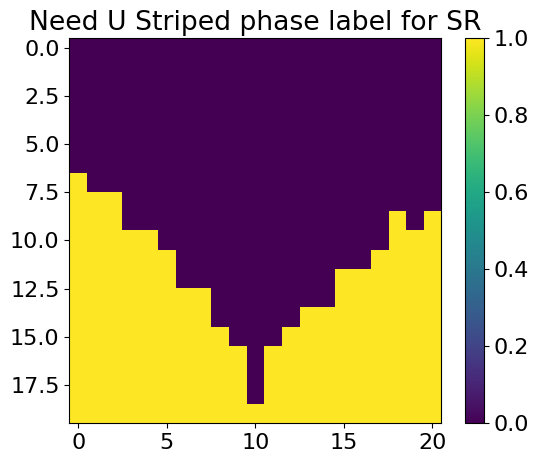

In [ ]:
threshold = 1.2
cluster_idx_in_both = jnp.argwhere(((mu0abs>threshold)*1 + (mu0abs>0.5)*1).transpose()!=1)

labels_both = jnp.zeros_like(jnp.mean(dataset.data, axis=(-1,-2)))
for id in cluster_idx_in_both:
  labels_both = labels_both.at[id[0],id[1]].set(1)
labels_both = labels_both[:,:].reshape(-1)


plt.rcParams['font.size'] = 16
plt.figure(figsize=(6,5),dpi=100)

plt.imshow(jnp.flipud(((mu0abs>threshold)*1 + (mu0abs>0.5)*1)!=1), aspect='auto')
plt.colorbar()
plt.title(r'Need U Striped phase label for SR')
plt.show()

In [ ]:
## this is just for development with nbdev (it tests the notebook and training take too much time so it skip it but in that case, for it not to fail, need to have non empty idx ##
if nbdev_test_mode: 
    cluster_idx_in_both = jnp.argwhere((data_exact['corr2_gs']<-5)*1 + (data_exact['corr2_gs']>5)*1)

### Start preparing the dataset ###
### Dataset prepared, start the trainnig ###
### Training finished ###
  message: CONVERGENCE: NORM OF PROJECTED GRADIENT <= PGTOL
  success: True
   status: 0
      fun: 0.5424128365853595
        x: [ 2.941e-01  2.223e-01 ...  3.068e-01  3.728e-01]
      nit: 25
      jac: [-1.255e-06 -4.741e-06 ... -1.654e-06 -5.440e-07]
     nfev: 1073
     njev: 29
 hess_inv: <36x36 LbfgsInvHessProduct with dtype=float64>


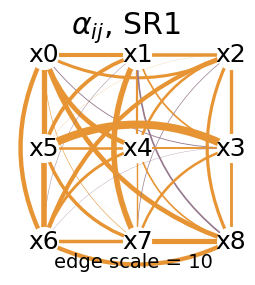

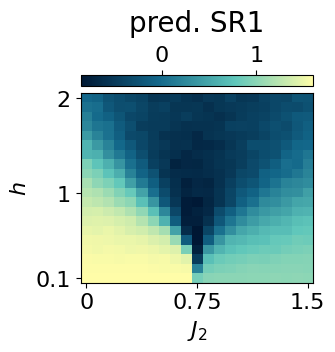

spearman between pred and exact corr:  0.92603844
auc:  0.9926067649281936


In [ ]:
## we then parform SR1 ##
mySR = SymbolicRegression(dataset, cluster_idx_in_both, objective='SR1', search_space = "2_body_correlator" )
key = jax.random.PRNGKey(432)
res = mySR.train(key, dataset_size=2000)

## plot the alpha ##
topology = [[0,1,2],[5,4,3],[6,7,8]]
mySR.plot_alpha(topology=topology, edge_scale=10, name='SR1')

## plot the prediction ##
p = mySR.compute_and_plot_prediction(name='SR1')

## containers to safe the results
all_alpha_both = {}
all_alpha_both['SR1'] = mySR.model.alpha
all_prediction_fx_both = {}
all_prediction_fx_both['SR1'] = p


## compute the spearman ##
#only on the left part of the parameter space where the Neel phase is
a = p[:,:].transpose().reshape(-1)
c = jnp.abs(data_exact['corr2_gs'])[:,:].reshape(-1)
s = jnp.abs(spearman_rho(a, c))

print('spearman between pred and exact corr: ', s)

## compute the auc ##
scores = p.transpose().reshape(-1)
auc = auc_from_scores_labels(scores, labels_both)

print('auc: ', auc)

### Start preparing the dataset ###
### Dataset prepared, start the trainnig ###
### Training finished ###
  message: CONVERGENCE: RELATIVE REDUCTION OF F <= FACTR*EPSMCH
  success: True
   status: 0
      fun: 9516.701464693555
        x: [ 9.209e-03  1.454e-01 ... -3.005e-01  1.625e+00]
      nit: 43
      jac: [-9.641e-03 -8.731e-03 ... -3.602e-02 -4.911e-03]
     nfev: 1739
     njev: 47
 hess_inv: <36x36 LbfgsInvHessProduct with dtype=float64>


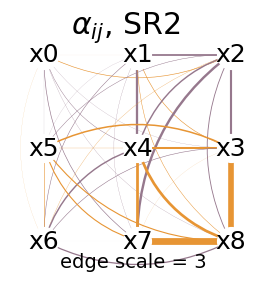

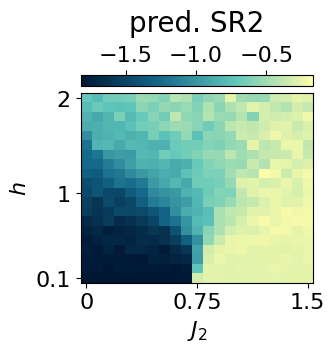

spearman between pred and exact corr:  0.029907348
auc:  0.4452003023431595


In [ ]:
## same but with the SR2 objective ##
mySR = SymbolicRegression(dataset,
                          cluster_idx_in_both,
                          objective='SR2',
                          idx_mu_cluster=latvar['id_lat'][0],
                          VAE_model=VAE_model,
                          VAE_params=VAE_params,
                          mu_cluster = mu0abs.transpose())

key = jax.random.PRNGKey(996)
res = mySR.train(key)

## plot the alpha ##
topology = [[0,1,2],[5,4,3],[6,7,8]]
mySR.plot_alpha(topology=topology, edge_scale=3, name='SR2')


## plot the prediction ##
p = mySR.compute_and_plot_prediction(name='SR2')


all_alpha_both['SR2'] = mySR.model.alpha
all_prediction_fx_both['SR2'] = p

## compute the spearman ##
a = p[:,:].transpose().reshape(-1)
c = jnp.abs(data_exact['corr2_gs'])[:,:].reshape(-1)
s = jnp.abs(spearman_rho(a, c))

print('spearman between pred and exact corr: ', s)

## compute the auc ##
scores = p.transpose().reshape(-1)
auc = auc_from_scores_labels(scores, labels_both)

print('auc: ', auc)

### Start preparing the dataset ###
small MLP training started...
step: 0, loss: 1.576394303301134
step: 200, loss: 0.03196585219250649
step: 400, loss: 0.02123169210771012
step: 600, loss: 0.01590317924216277
step: 800, loss: 0.012976589405386327
step: 1000, loss: 0.011107755500393899
step: 1200, loss: 0.00944290268236954
step: 1400, loss: 0.007798434789637364
step: 1600, loss: 0.006656533240128291
step: 1800, loss: 0.00588472514212625
small MLP training finished!


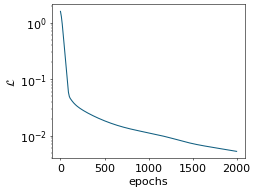

### Dataset prepared, start the trainnig ###
### Training finished ###
  message: CONVERGENCE: NORM OF PROJECTED GRADIENT <= PGTOL
  success: True
   status: 0
      fun: 2.4961066208643406e-05
        x: [ 7.060e-02 -3.002e-01 ... -2.732e-01  2.172e-03]
      nit: 2
      jac: [-1.351e-06  9.870e-10 ... -2.414e-07 -6.763e-07]
     nfev: 111
     njev: 3
 hess_inv: <36x36 LbfgsInvHessProduct with dtype=float64>


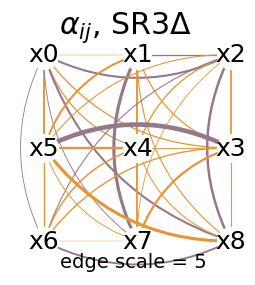

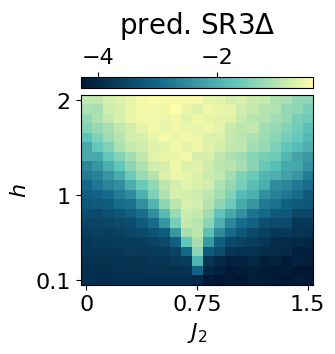

spearman between pred and exact corr:  0.98329
auc:  0.9974962207105065


In [ ]:
## same but with the SR3 delta objective ##
mySR = SymbolicRegression(dataset, cluster_idx_in_both, objective='SR3',
                                type_of_vk = 'delta',
                                idx_mu_cluster=latvar['id_lat'][0],
                                VAE_model=VAE_model,
                                VAE_params=VAE_params,
                                mu_cluster = mu0abs.transpose())
key = jax.random.PRNGKey(439)
res = mySR.train(key)

## plot the alpha ##
mySR.plot_alpha(topology=topology, edge_scale=5, name=r'SR3$\Delta$')

## plot the prediction ##
p = mySR.compute_and_plot_prediction(name=r'SR3$\Delta$')

all_alpha_both['SR3delta'] = mySR.model.alpha
all_prediction_fx_both['SR3delta'] = p

## compute the spearman ##
a = p[:,:].transpose().reshape(-1)
c = jnp.abs(data_exact['corr2_gs'])[:,:].reshape(-1)
s = jnp.abs(spearman_rho(a, c))

print('spearman between pred and exact corr: ', s)

## compute the auc ##
scores = p.transpose().reshape(-1)
auc = auc_from_scores_labels(scores, labels_both)

print('auc: ', 1-auc)

### Start preparing the dataset ###
small MLP training started...
step: 0, loss: 0.8237394599047482
step: 200, loss: 0.02007031511076417
step: 400, loss: 0.012619977088312062
step: 600, loss: 0.007273144612003008
step: 800, loss: 0.005120754765966418
step: 1000, loss: 0.004348286592244995
step: 1200, loss: 0.003982990246148514
step: 1400, loss: 0.0037789074312997747
step: 1600, loss: 0.003635713811519585
step: 1800, loss: 0.0035250841485587347
small MLP training finished!


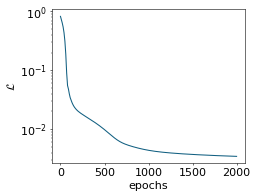

### Dataset prepared, start the trainnig ###
### Training finished ###
  message: CONVERGENCE: NORM OF PROJECTED GRADIENT <= PGTOL
  success: True
   status: 0
      fun: 2.5154335298421515e-05
        x: [ 1.482e-02  1.880e-01 ...  5.220e-01  1.305e-01]
      nit: 1
      jac: [-7.356e-07  9.682e-07 ...  4.667e-06 -3.522e-06]
     nfev: 74
     njev: 2
 hess_inv: <36x36 LbfgsInvHessProduct with dtype=float64>


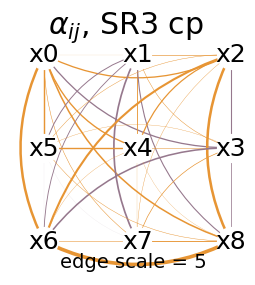

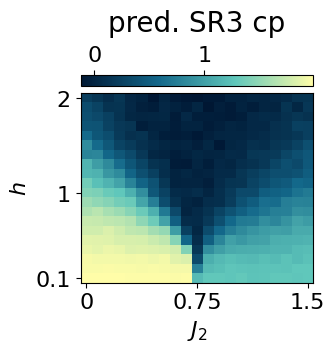

spearman between pred and exact corr:  0.931234
auc:  0.9921815948601663


In [ ]:
## same but with the SR3 cp objective ##
mySR = SymbolicRegression(dataset, cluster_idx_in_both, objective='SR3',
                                type_of_vk = 'cp',
                                idx_mu_cluster=latvar['id_lat'][0],
                                VAE_model=VAE_model,
                                VAE_params=VAE_params,
                                mu_cluster = mu0abs.transpose())
key = jax.random.PRNGKey(54631)
model = mySR.train(key)

## plot the alpha ##
mySR.plot_alpha(topology=topology, edge_scale=5, name='SR3 cp')

## plot the prediction ##
p = mySR.compute_and_plot_prediction(name='SR3 cp')

all_alpha_both['SR3cp'] = mySR.model.alpha
all_prediction_fx_both['SR3cp'] = p

## compute the spearman ##
a = p[:,:].transpose().reshape(-1)
c = jnp.abs(data_exact['corr2_gs'])[:,:].reshape(-1)
s = jnp.abs(spearman_rho(a, c))

print('spearman between pred and exact corr: ', s)

## compute the auc ##
scores = p.transpose().reshape(-1)
auc = auc_from_scores_labels(scores, labels_both)

print('auc: ', auc)

In [ ]:
## also add the data and the exact corr ##

all_data['alpha_neel'] = all_alpha_neel
all_data['prediction_fx_neel'] = all_prediction_fx_neel
all_data['alpha_striped'] = all_alpha_striped
all_data['prediction_fx_striped'] = all_prediction_fx_striped
all_data['alpha_both'] = all_alpha_both
all_data['prediction_fx_both'] = all_prediction_fx_both


small MLP training started...
step: 0, loss: 0.9270867264153914
step: 200, loss: 0.025365141924426824
step: 400, loss: 0.0205801099063303
step: 600, loss: 0.01540809492343725
step: 800, loss: 0.009861195764288247
step: 1000, loss: 0.006851133800208942
step: 1200, loss: 0.0053762430287735705
step: 1400, loss: 0.004806366592313117
step: 1600, loss: 0.004431803405626902
step: 1800, loss: 0.004128424340035682
small MLP training finished!


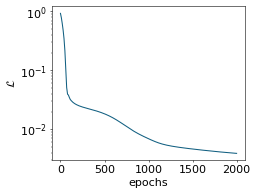

In [ ]:
## plus some other values needed for some plots
mySR = SymbolicRegression(dataset, cluster_idx_in_neel, objective='SR3',
                                type_of_vk = 'delta',
                                idx_mu_cluster=latvar['id_lat'][0],
                                VAE_model=VAE_model,
                                VAE_params=VAE_params,
                                mu_cluster = mu0abs.transpose())
key = jax.random.PRNGKey(89)
G = mySR.get_grad_mu_wrt_theta_SR3(key, cluster_idx_in_neel)
all_data['grad_mu1_neel_boundaries'] = G

In [ ]:
with open('J1J2_data_cpVAE2_QDisc.pkl', 'wb') as f:
    pickle.dump(all_data, f)